# Bias and Fairness Analysis in Income Prediction Model

## Objective
This notebook evaluates whether the trained machine learning model exhibits bias across demographic groups such as gender and race.

The goal is to assess fairness by comparing:
- Model accuracy across groups
- Positive prediction rates across groups

This analysis is critical for ensuring ethical AI in high-stakes decision systems.

In [19]:
#imports 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
#loading cleaned dataset

df = pd.read_csv("../data/adult_cleaned.csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


# Recreating Trrain/test

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reusing the trained model

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Model pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

/var/folders/z9/n05_4yyd2jd8plxt4l883pww0000gn/T/ipykernel_67159/3435843999.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [23]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [24]:
y_pred = rf_pipeline.predict(X_test)

In [25]:
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

# Building the result Daframe

In [26]:
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred

results.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,actual,predicted
217,28,Private,76714,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,55,United-States,1,0
24913,41,Private,178431,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,Taiwan,0,0
17780,53,Private,290640,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,50,Germany,1,0
12484,31,Private,215297,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,45,United-States,0,0
8890,34,Local-gov,188682,Bachelors,13,Married-spouse-absent,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,0,0


# Accuracy by gender

In [27]:
gender_group = results.groupby("sex").apply(
    lambda x: pd.Series({
        "accuracy": (x["actual"] == x["predicted"]).mean(),
        "count": len(x)
    })
)

gender_group

,accuracy,count
sex,,
Female,0.926058,1961.0
Male,0.817289,4072.0


# Accuracy by race

In [28]:
race_group = results.groupby("race").apply(
    lambda x: pd.Series({
        "accuracy": (x["actual"] == x["predicted"]).mean(),
        "count": len(x)
    })
)

race_group

,accuracy,count
race,,
Amer-Indian-Eskimo,0.944444,54.0
Asian-Pac-Islander,0.860963,187.0
Black,0.914931,576.0
Other,0.900000,40.0
White,0.844088,5176.0


# Positive predictive rate by group

In [29]:
gender_positive = results.groupby("sex")["predicted"].mean()
race_positive = results.groupby("race")["predicted"].mean()

print("Positive prediction rate by gender:")
print(gender_positive)

print("\nPositive prediction rate by race:")
print(race_positive)

Positive prediction rate by gender:
sex
Female    0.091280
Male      0.282908
Name: predicted, dtype: float64

Positive prediction rate by race:
race
Amer-Indian-Eskimo    0.092593
Asian-Pac-Islander    0.262032
Black                 0.102431
Other                 0.150000
White                 0.234158
Name: predicted, dtype: float64


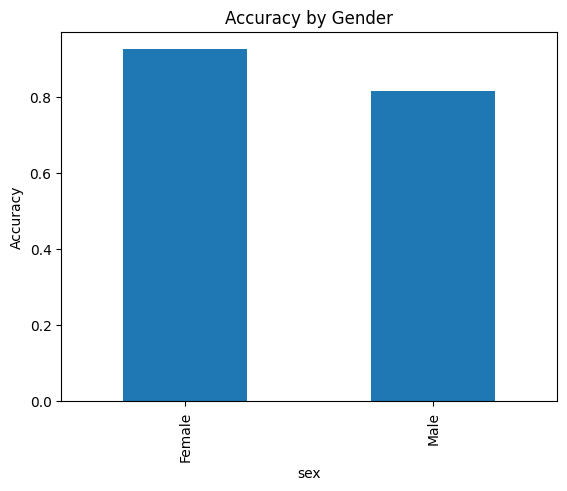

In [30]:
# Simple Plots

gender_group["accuracy"].plot(kind="bar", title="Accuracy by Gender")
plt.ylabel("Accuracy")
plt.show()

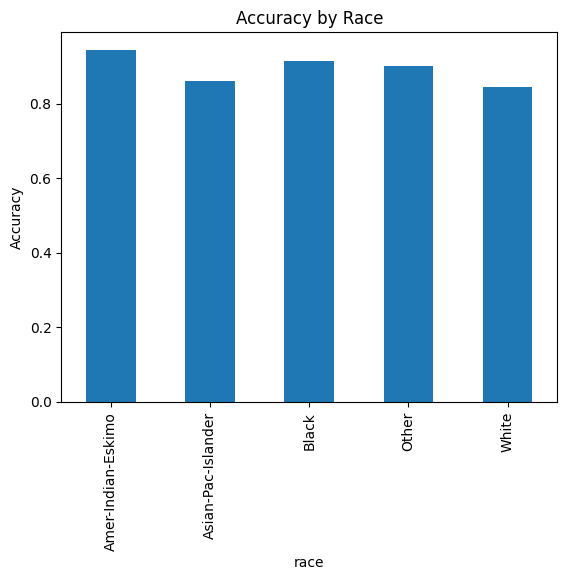

In [31]:
race_group["accuracy"].plot(kind="bar", title="Accuracy by Race")
plt.ylabel("Accuracy")
plt.show()

In [32]:
# saving the results

gender_group.to_csv("../results/gender_bias.csv")
race_group.to_csv("../results/race_bias.csv")
gender_positive.to_csv("../results/gender_positive_rate.csv")
race_positive.to_csv("../results/race_positive_rate.csv")

## Interpretation

The fairness analysis shows whether model performance and prediction patterns vary across demographic groups. Differences in accuracy and positive prediction rates may indicate unequal model behaviour across sex and race categories. This is important in high-stakes decision systems because unequal outcomes may reflect or amplify existing social biases.